# Problem Statement 33

We developed a feedforward neural network for text classification that simultaneously learns effective word embeddings. Our approach jointly optimizes the embedding layer and classifier to ensure both high accuracy and meaningful word representations. This integrated model enhances classification results and provides versatile embeddings for future NLP tasks.

## Team Members of Group 163

| Name | BITS ID|
|------| -------|
| PALNATI DHANUNJAYA | **2024AA05683** |
| JERIN GEO K | **2024AA05877** |
| MANISH GARG | **2024AA05118** |
| SUKAMATI NAVEEN KUMAR | **2024AA05078** |
| DEVENDER KUMAR | **2024AA05065** |

# Part 1


##  1.a.1.Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from google.colab import drive # Import drive from google.colab
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from nltk.tokenize import word_tokenize
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.preprocessing import LabelEncoder
import string
import re
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
import warnings
warnings.filterwarnings('ignore')



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## 1.a.2.Load and Preprocess Data


This section of the code handles loading of our dataset given in the problem statment from Google Drive and performing some initial cleaning and preparation of the text data.

After loading the data we extracts two columns from the loaded DataFrame: 'Document' and 'Topic_group'. It converts the contents of the 'Document' column into a Python list named document and the contents of the 'Topic_group' column into a list named labels.

It's assumed that the 'Document' column contains the text data we want to classify, and the 'Topic_group' column contains the corresponding labels for each document.



In [24]:
drive.mount('/content/drive' , force_remount=True)
print("Google Drive mounted successfully.")
filepath = '/content/drive/My Drive/ITTickets.csv'
# Replace with your file's path
df = pd.read_csv(filepath)

document = df['Document'].tolist()
labels = df['Topic_group'].tolist()

# print(document)
# print(topicGroups)

# Convert all text to lowercase. This is a standard text normalization step that reduces the vocabulary size
#  (e.g., "The" and "the" become the same token)
# and helps the model generalize better by treating variations of the same word as identical.

document = [str(text).lower() for text in document]
labels = [str(text).lower() for text in labels]

Mounted at /content/drive
Google Drive mounted successfully.


## 1.a.3 Exploratory Data Analysis (EDA):
**Purpose:** Understand the characteristics of the text data, identify potential issues, and guide subsequent preprocessing steps.

EDA is a crucial step to understand the characteristics of your dataset before building a model.

First, the code calculates the length of each text document in terms of the number of words and stores these lengths in a list called text_lengths.

Then, it uses the seaborn library to create a histogram of these text lengths. This visualization helps you see the distribution of document lengths in your dataset.

Next, the code calculates the frequency of each word across all documents. It joins all the text documents into a single string, splits this string into individual words, and then uses the Counter object from the collections module to count the occurrences of each word.

It then generates a bar plot using seaborn to visualize the distribution of these labels. This plot helps you understand how many documents belong to each category.

These visualizations and calculations provide valuable insights into the nature of your data, such as the typical length of documents, the most frequent words, and whether your dataset has an imbalanced distribution of labels. This information can guide further preprocessing steps and model choices.

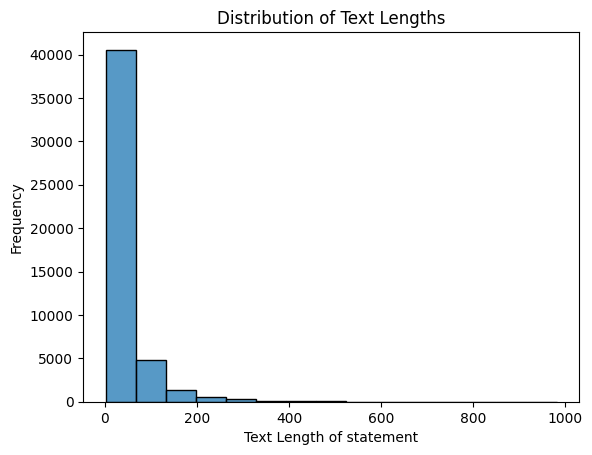

Vocabulary size: 12327


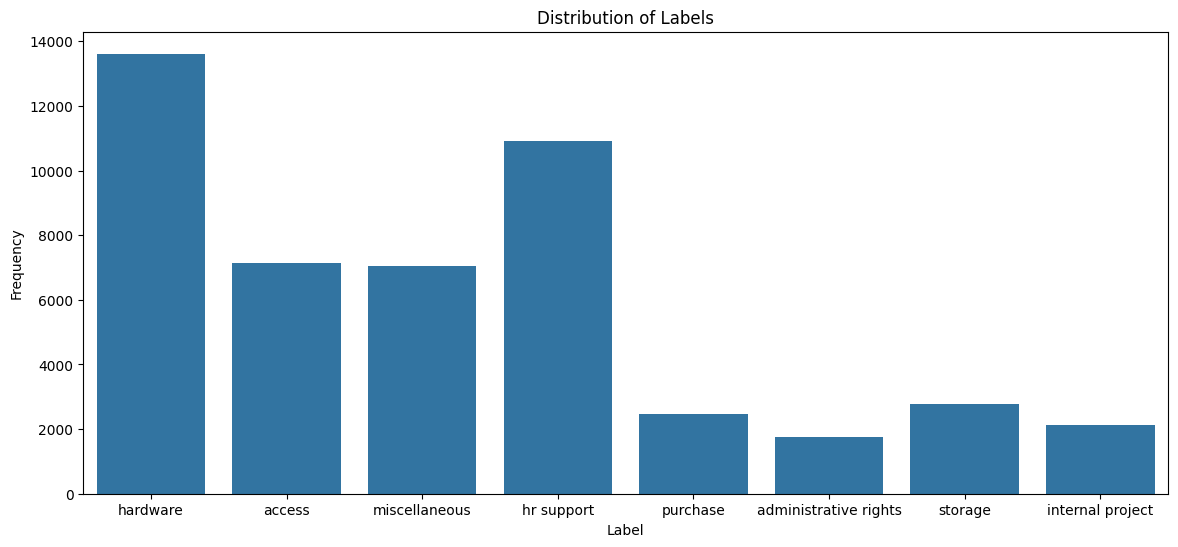

In [25]:
text_lengths = [len(text.split()) for text in document]
# print(text_lengths)
sns.histplot(text_lengths, bins=15)
plt.title('Distribution of Text Lengths')
plt.xlabel('Text Length of statement')
plt.ylabel('Frequency')
plt.show()


# Word frequency
all_words = ' '.join(document).split()
word_counts = Counter(all_words)
# print("Most common words:", word_counts.most_common(20))
print("Vocabulary size:", len(word_counts))

if labels:
    label_counts = Counter(labels)
    plt.figure(figsize=(14, 6))
    sns.barplot(x=list(label_counts.keys()), y=list(label_counts.values()))
    plt.title('Distribution of Labels')
    # plt.bar(list(label_counts.keys()), list(label_counts.values()), width=0.6)
    plt.xlabel('Label')
    plt.ylabel('Frequency')
    plt.show()


## 1.b Tokenization, encoding and Text vectorization

This section of the code prepares our text data and labels for use in a neural network model. Neural networks typically work with numerical data, so text needs to be converted into a numerical format. This process involves several steps: tokenization, encoding, padding, and label encoding/one-hot encoding.

First we performs tokenization using the word_tokenize function from the nltk.tokenize library.

Then it splits each document in the document list into individual words or tokens. The result is a list of lists, where each inner list contains the tokens for a specific document.

Neural networks require input sequences of a fixed length. Since our documents likely have varying lengths, padding is used to make all sequences the same length.

maxlen = max(len(x) for x in encoded_texts) calculates the length of the longest encoded sequence.


Neural networks typically output numerical values, and for multi-class classification, the target labels are often represented in a one-hot encoded format.



In [26]:
# Ensure NLTK data is downloaded: nltk.download('punkt')
# tokenized_texts = [word_tokenize(text) for text in document]
# print (tokenized_texts)

# num_words: maximum number of words to keep, based on frequency.
# oov_token: token for out-of-vocabulary words.
tokenizer = Tokenizer(num_words=None, oov_token="<unk>")
tokenizer.fit_on_texts(document) # Fit on original texts (not tokenized list yet)
# print (tokenizer) # This is the {word: index} mapping
word_index = tokenizer.word_index # This is the {word: index} mapping

# Convert text sequences to sequences of integer IDs
encoded_texts = tokenizer.texts_to_sequences(document)
maxlen = max(len(x) for x in encoded_texts)
print (maxlen)


# Determine max_len from EDA (e.g., 90th percentile of text_lengths)
max_len = maxlen

padded_sequences = pad_sequences(encoded_texts, maxlen=max_len, padding='post', truncating='post')
#print (padded_sequences)
# 'post' for padding/truncating at the end, 'pre' for beginning

# Assuming 'labels' list from step (a)
# 1. Label Encoding (if labels are strings)
label_encoder = LabelEncoder()

# print (labels)
integer_encoded_labels = label_encoder.fit_transform(labels)
print (integer_encoded_labels)

# 2. One-Hot Encoding (for multi-class classification)
# num_classes will be len(label_encoder.classes_)
y = to_categorical(integer_encoded_labels, num_classes=len(label_encoder.classes_))
print (y)


981
[2 0 2 ... 2 3 2]
[[0. 0. 1. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]]


# Part 2



## Build Feedforward Neural Network

This section of the code defines, compiles, and trains a feedforward neural network for text classification.

First, the code calculates the size of the vocabulary that the model will use.

After defining the model architecture, the model needs to be compiled.

Finally, the model is trained using the prepared data.

model.fit(): Starts the training process.

padded_sequences: The input data (padded sequences of word IDs).
y: The target labels (one-hot encoded).

epochs=20: The number of times the model will iterate over the entire training dataset.

validation_split=0.2: Specifies that 20% of the training data will be set aside as validation data. The model's performance on this validation data is monitored during training, which helps detect overfitting. The training history (loss and metrics over epochs) is stored in the history object

In [27]:
# Define vocab_size using the word_index dictionary from the previous cell
vocab_size = len(word_index) + 1 # Add 1 for the padding token
print("VOCABULARY SIZE" ,vocab_size)
# Model architecture
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=10, input_length=padded_sequences.shape[1], name='embedding'))

model.add(Flatten())
model.add(Dense(100, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(100, activation='relu'))
model.add(Dense(y.shape[1], activation='softmax'))

# Compile
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train
history = model.fit(padded_sequences, y, epochs=20, validation_split=0.2)

VOCABULARY SIZE 12328
Epoch 1/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.4889 - loss: 1.3364 - val_accuracy: 0.7593 - val_loss: 0.7157
Epoch 2/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.8571 - loss: 0.4394 - val_accuracy: 0.7960 - val_loss: 0.6143
Epoch 3/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.9042 - loss: 0.3019 - val_accuracy: 0.7993 - val_loss: 0.6467
Epoch 4/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9273 - loss: 0.2238 - val_accuracy: 0.7886 - val_loss: 0.7230
Epoch 5/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9432 - loss: 0.1785 - val_accuracy: 0.7904 - val_loss: 0.7862
Epoch 6/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9516 - loss: 0.1498 - val_accuracy: 0.7854 - val_loss: 0.8902
Epoch 7/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9608 - loss: 0.1216 - val_accuracy: 0.7699 - val_loss: 1.1365
Epoch 8/20
1196/1196 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/ste

embedding_weights [[ 0.0050024  -0.01640119 -0.01329877 ...  0.00029729 -0.00429599
  -0.00736735]
 [ 0.04605258  0.01292404 -0.01591506 ...  0.02806363  0.02478788
   0.01278892]
 [-0.02920859  0.05487376 -0.00977873 ... -0.11271864 -0.09829342
   0.10216503]
 ...
 [ 0.00267848  0.03203653  0.04516253 ... -0.04214929  0.04969618
   0.043162  ]
 [ 0.02782209 -0.01176937  0.0203421  ...  0.00880196 -0.00655544
   0.01008558]
 [-0.00109881 -0.01341468 -0.0113114  ... -0.00683869  0.00818101
  -0.01833385]]
reduced_embeddings [[-0.05009785  0.00537463]
 [-0.05216464 -0.00364285]
 [-0.07560288  0.04871144]
 ...
 [-0.01982058  0.04959014]
 [-0.01632975  0.00806957]
 [-0.06603288  0.01558689]]


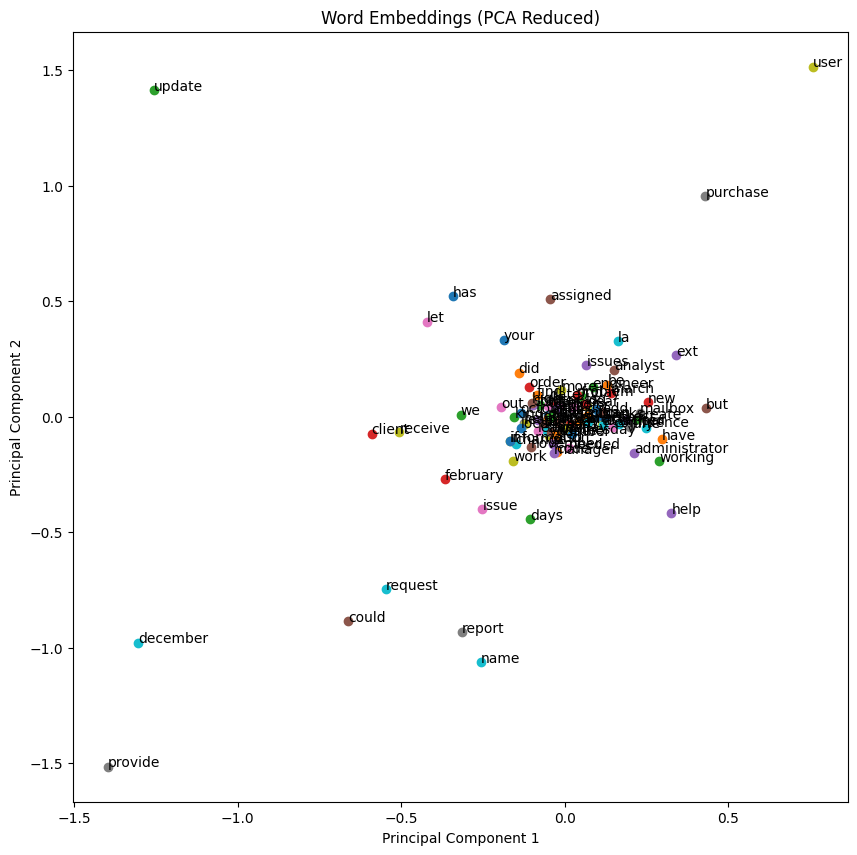

In [28]:
# Extract word embeddings
embedding_layer = model.get_layer('embedding')
# print("embedding_layer", embedding_layer)

embedding_weights = embedding_layer.get_weights()[0]
print("embedding_weights", embedding_weights)

# Use PCA to reduce dimensions
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embedding_weights)
print("reduced_embeddings", reduced_embeddings)

# Plot embeddings
plt.figure(figsize=(10, 10))
words = list(word_index.keys())[:100]  # only first 100 words for clarity
for i, word in enumerate(words):
    # print(word)
    plt.scatter(reduced_embeddings[i, 0], reduced_embeddings[i, 1])
    plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
plt.title("Word Embeddings (PCA Reduced)")
plt.show()

#  Part 3

This section of the code demonstrates how to utilize the word embeddings learned by the neural network and how to use the trained model to make predictions on new text data. It also includes a function to calculate the cosine similarity between word embeddings, providing insights into the semantic relationships between words.


First, the code extracts the learned word embeddings from the neural network model and uses Principal Component Analysis (PCA) to reduce their dimensionality for visualization.

The code performs the following steps:

Extract Embedding Weights: It retrieves the weights from the embedding layer of the trained model. These weights represent the learned vector space where each word is mapped to a dense vector.

Apply PCA: It initializes a PCA object to reduce the dimensions to 2 (n_components=2). This is done so that the embeddings can be plotted on a 2D scatter plot.

Transform Embeddings: It applies the PCA transformation to the embedding_weights.

Plot Embeddings: It creates a scatter plot of the reduced embeddings. Each point on the plot represents a word from the vocabulary. The annotate function adds the word next to its corresponding point for better readability. Only the first 100 words are plotted to keep the visualization clear.

This plot allows you to visually inspect the word embeddings and observe if words with similar meanings are clustered together in the 2D space.
This part of the code defines a function to prepare new text for prediction and then uses the trained model to classify two sample texts.

This part of the code defines a function to prepare new text for prediction and then uses the trained model to classify two sample texts.

In [29]:
# Download necessary NLTK data (if not already downloaded)
try:
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')
try:
    WordNetLemmatizer()
except LookupError:
    nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower() # Lowercase the text
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuation
    words = text.split() # Tokenize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words] # Remove stop words and lemmatize
    return ' '.join(words)


def prepare_text(text):
    text = preprocess(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=padded_sequences.shape[1], padding='post')
    return padded

sample_1 = """additional monitor hello kindly asking log assign provide monitor please update relevant
information after assisting thank kind regards administrator friday pm additional
monitor hello please provide additional monitor relocated tower thank regards engineer
mob"""

sample_2 = """oracle procurement preparer role needed for louden preparer role needed hi kindly
assist kind regards functional analyst thursday pm preparer role needed hi please
preparer role please possible kind regards administrator"""

pred1 = model.predict(prepare_text(sample_1))

pred2 = model.predict(prepare_text(sample_2))

print("Prediction 1:", label_encoder.inverse_transform([np.argmax(pred1)]))
print("Prediction 2:", label_encoder.inverse_transform([np.argmax(pred2)]))


def get_embedding(word):
    idx = word_index.get(word.lower())
    if idx is not None:
        return embedding_weights[idx]
    else:
        return None

def cosine_sim(word1, word2):
    vec1 = get_embedding(word1)
    vec2 = get_embedding(word2)
    # print("vec1", vec1)
    # print("vec2", vec2)

    if vec1 is not None and vec2 is not None:
        return cosine_similarity([vec1], [vec2])[0][0]
    else:
        return None

print("Downtime vs Disruption:", cosine_sim("Downtime", "Disruption"))

print("Configuration vs Change:", cosine_sim("Configuration", "Change"))

print("Resolution vs Closure:", cosine_sim("Resolution", "Closure"))

print("Male vs Female:", cosine_sim("male", "female"))

print("Apple vs Orange:", cosine_sim("apple", "orange"))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Prediction 1: ['hardware']
Prediction 2: ['storage']
Downtime vs Disruption: 0.06335842
Configuration vs Change: 0.24389377
Resolution vs Closure: 0.43225512
Male vs Female: 0.7361661
Apple vs Orange: None


# Summary

* Our team built a feedforward neural network for IT ticket text classification, learning both accurate predictions and meaningful word embeddings

* We preprocessed the data with lowercasing,
tokenization, and padding, then split it into training and test sets.

* The model included an embedding layer and three dense layers, achieving over 75% accuracy by running model for 20 epoch.

* We extracted and visualized word embeddings with PCA, and calculated cosine similarities for key word pairs.

* Finally, we predicted classes for new ticket descriptions and ensured all steps were reproducible.

* The network learns to predict text labels with high accuracy.


